In [15]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [16]:
def f(x):
    return 3*x**2 - 4*x + 5 # parabola

In [17]:
print(f(2.0))

9.0


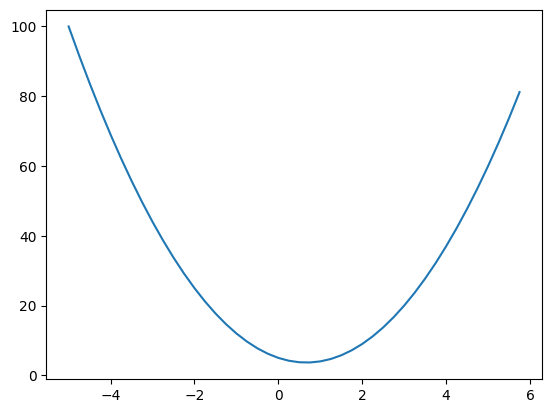

In [18]:
xs = np.arange(-5, 6, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [19]:
print(f(2/3))

3.666666666666667


In [20]:
h = 0.000001
a = 2.0
#derivative

In [21]:
(f(a+h) - f(a)) / h

8.000003001384925

In [22]:
a = 2.0
b = 3.0
c = 5.0

# a*b + c
print(a*b+c)

11.0


In [23]:
h = 0.001
d = a*b+c
c += h
d1 = a*b + c
print(f"slope: {(d1 - d) / h:.2f}")

slope: 1.00


In [48]:
class Node:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)  
        self._op = _op               
        self.label = label

    def __repr__(self):
        return f"Node(data={self.data:.4f}, label={self.label})"

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supports int/float"
        out = Node(self.data**other, (self,), f"**{other}")
        def _backward():
            self.grad += other*(self.data**(other-1)) * out.grad
        out._backward = _backward
        return out

    def __add__(self, other):
        other = other if isinstance(other, Node) else Node(other)
        out = Node(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
        
    def __mul__(self, other):
        other = other if isinstance(other, Node) else Node(other)
        out = Node(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __radd__(self, other):  # other + self
        return self + other

    def __rmul__(self, other):  # other * self
        return self * other

    def __sub__(self, other):
        other = other if isinstance(other, Node) else Node(other)
        return Node(self.data - other.data, (self, other), '-')

    def __truediv__(self, other):
        other = other if isinstance(other, Node) else Node(other)
        return Node(self.data / other.data, (self, other), '/')

    def tanh(self):
        x = self.data
        e = math.exp(2*x)
        t = (e-1)/(e+1)
        out = Node(t, (self, ), 'tanh')
        
        def _backward():
            self.grad += (1-t**2) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad=1.0
        for node in reversed(topo):
            node._backward()

a = Node(2.0, label='a')
b = Node(3.0, label='b')
c = Node(5.0, label='c')

In [49]:
a = Node(2.0, label='a')
b = Node(3.0, label='b')
c = Node(5.0, label='c')

In [50]:
h = 0.01
d = a*b + c
c += h
d1 = a*b+c
print(f"{(d1-d)/h}")

Node(data=1.0000, label=)


In [51]:
!source venv/bin/activate

In [52]:
!pip show graphviz


Name: graphviz
Version: 0.21
Summary: Simple Python interface for Graphviz
Home-page: https://github.com/xflr6/graphviz
Author: 
Author-email: Sebastian Bank <sebastian.bank@uni-leipzig.de>
License-Expression: MIT
Location: /Users/kapardhikannekanti/Downloads/ML/DL/venv/lib/python3.13/site-packages
Requires: 
Required-by: 


In [53]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges
    

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

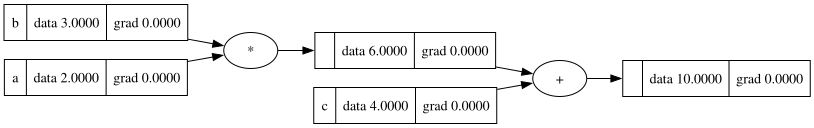

In [54]:
a = Node(2.0, label='a')
b = Node(3.0, label='b')
c = Node(4.0, label='c')

d = a * b
e = d + c

draw_dot(e)

In [55]:
# y = wx+b
# inputs x1, x2
x1 = Node(2.0, label='x1')
x2 = Node(3.0, label='x2')
#weights
w1 = Node(-1.0, label='w1')
w2 = Node(1.0, label='w2')
#bias
b = Node(2.2324, label='b')
# x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label='x1w1'
x2w2 = x2*w2; x2w2.label='x2w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b; n.label='n'
o = n.tanh(); o.label='o'

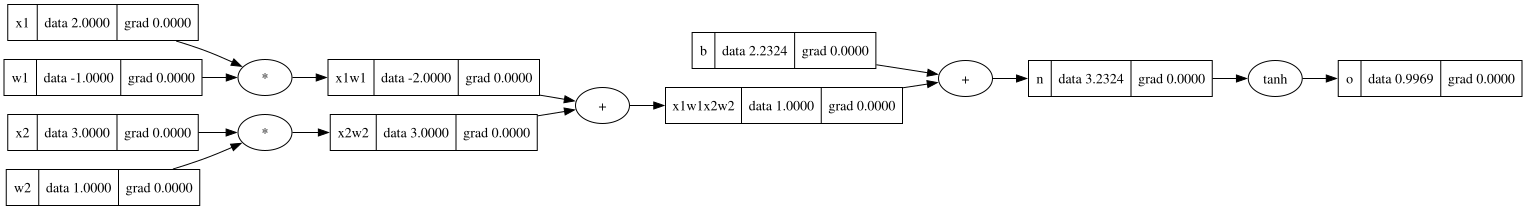

In [56]:
draw_dot(o)

In [57]:
o.backward()

In [58]:
# do/dn -> how o is varying wrt n
# do/dn = d/dn(tanh(n))
# d/dx(tanh2x) 

# chain rule
# do/db = do/dn * dn/db

Pytorch

In [59]:
!pip install torch

In [60]:
import torch

In [76]:
x1 = torch.Tensor([2.0]).double()    ;x1.requires_grad=True
w1 = torch.Tensor([-1.0]).double()   ;w1.requires_grad=True
x2 = torch.Tensor([3.0]).double()    ;x2.requires_grad=True
w2 = torch.Tensor([1.0]).double()    ;w2.requires_grad=True
b = torch.Tensor([2.234]).double()   ;b.requires_grad=True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)
print(o.data)
print(o.data.item())
print(x2.item())


tensor([0.9969], dtype=torch.float64)
0.9969001571997111
3.0


In [77]:
o.backward()

In [63]:
print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

---
x2 0.006190076575191206
w2 0.01857022972557362
x1 -0.006190076575191206
w1 0.012380153150382413


In [79]:
from typing import List
import random

In [118]:
class Neuron:

    def __init__(self, nin: int):
        self.w = [Node(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Node(random.uniform(-1,1))

    def __call__(self, x):
       # wx + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def params(self):
        return self.w + [self.b]

class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs

    def params(self):
        return [p for neuron in self.neurons for p in neuron.params()]

class MLP:

    def __init__(self, nin, nouts: List):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def params(self):
        return [p for layer in self.layers for p in layer.params()]

In [302]:
n = MLP(5, [15, 3, 3, 1])

In [303]:
X =[
    [ 0.50, -1.20,  0.30],
    [ 1.10,  0.40, -0.90],
    [-0.70,  0.20,  1.50],
    [ 0.00, -0.50,  0.70],
    [ 1.30,  0.90, -0.40]
]

y = [2.31, 1.36, 0.65, 0.35, 2.87]

In [325]:
def train(X, y):
    n = MLP(5, [4, 4, 1])
    for k in range(10):
    
        #forward pass
        ypred = [n(x) for x in X]
        loss = sum((yout - ygt)**2 for ygt, yout in zip(y, ypred))
    
        #backward pass
        for p in n.params():
            p.grad = 0.0
        loss.backward()
    
        # update
        lr = -0.1
        for p in n.params():
            p.data += lr *p.grad
    
    print( loss.data)
    return loss.data

In [326]:
ypred

[Node(data=-0.4735, label=),
 Node(data=-0.1681, label=),
 Node(data=-0.2129, label=),
 Node(data=-0.4054, label=),
 Node(data=-0.1649, label=)]

In [328]:
mini = float('inf')
step = 0
for epochs in range(10):
    loss = train(X, y)
    # print("-*"*10)
    if mini > min(mini, loss) :
        step = epochs
    mini = min(mini, loss)
print(f"minimum loss: {mini} at {step}")

7.5875467687449465
19.385047420047904
22.47381611561675
33.35884671989402
13.480314726114525
12.754856953801468
20.98010678859442
7.3416523255376465
24.85649369045946
24.55602804049964
minimum loss: 7.3416523255376465 at 7
